# Task 3: ARX model


In [2]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [3]:
data = pd.read_csv('box_data_60min.csv', header=0, index_col="thour", parse_dates=["tdate"])
data.head()

,tdate,Ph,Tdelta,Gv,Ph.l0,Ph.l1,Ph.l2,Ph.l3,Ph.l4,Ph.l5,...,Gv.l1,Gv.l2,Gv.l3,Gv.l4,Gv.l5,Gv.l6,Gv.l7,Gv.l8,Gv.l9,Gv.l10
thour,,,,,,,,,,,,,,,,,,,,,
19,2013-01-30 02:00:00,56,13.253583,-0.498643,56,55,57,57,58,59,...,-0.499338,-0.417959,-0.221011,-0.453375,-0.747238,-0.669267,-0.451776,-0.142700,8.262339,20.475484
20,2013-01-30 03:00:00,54,13.181458,-1.127035,54,56,55,57,57,58,...,-0.498643,-0.499338,-0.417959,-0.221011,-0.453375,-0.747238,-0.669267,-0.451776,-0.142700,8.262339
21,2013-01-30 04:00:00,55,12.968792,-0.643298,55,54,56,55,57,57,...,-1.127035,-0.498643,-0.499338,-0.417959,-0.221011,-0.453375,-0.747238,-0.669267,-0.451776,-0.142700
22,2013-01-30 05:00:00,54,12.667750,-0.456008,54,55,54,56,55,57,...,-0.643298,-1.127035,-0.498643,-0.499338,-0.417959,-0.221011,-0.453375,-0.747238,-0.669267,-0.451776
23,2013-01-30 06:00:00,54,12.605250,-1.534060,54,54,55,54,56,55,...,-0.456008,-0.643298,-1.127035,-0.498643,-0.499338,-0.417959,-0.221011,-0.453375,-0.747238,-0.669267


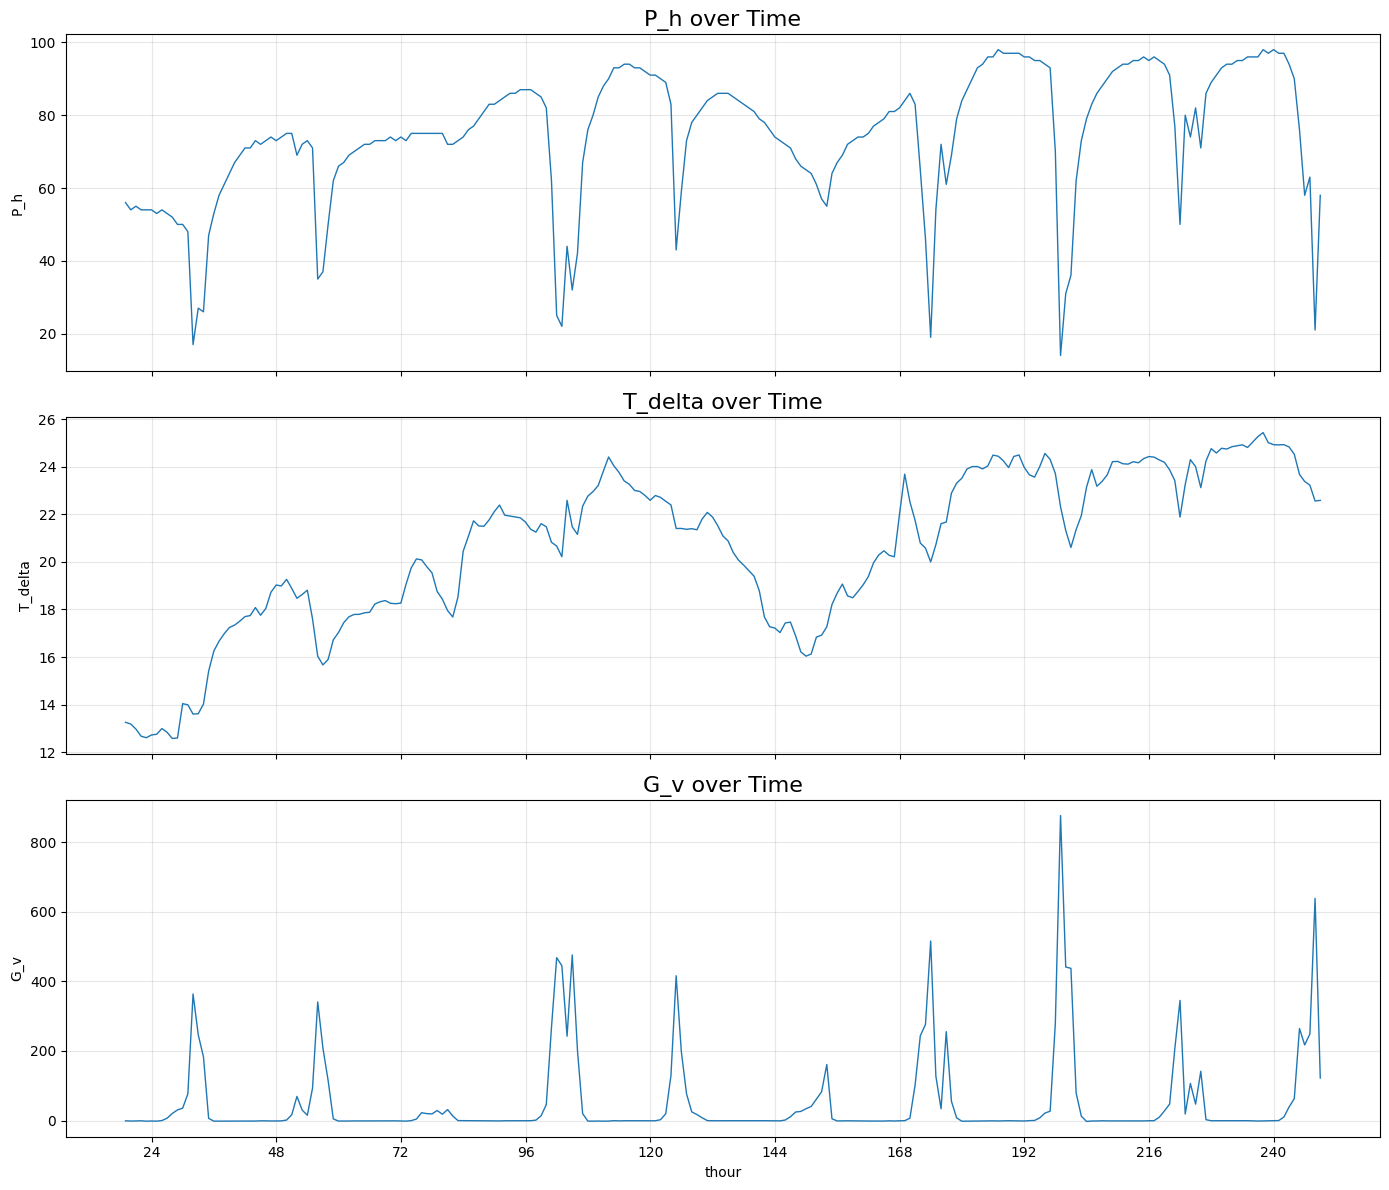

In [4]:
from matplotlib.ticker import MultipleLocator

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

series_to_plot = [
    ("Ph", "P_h", "P_h over Time"),
    ("Tdelta", "T_delta", "T_delta over Time"),
    ("Gv", "G_v", "G_v over Time"),
]

for ax, (col, name, title) in zip(axes, series_to_plot):
    ax.plot(data.index, data[col], linewidth=1)
    ax.set_title(title, fontsize=16)
    ax.set_ylabel(name)
    ax.xaxis.set_major_locator(MultipleLocator(24))
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("thour")
plt.tight_layout()
plt.show()

## Splitting the data into train and test
The data is split into a train and test set, such that ”2013-02-06 00:00” is the last data point in the training set (i.e. thour = 1,...,167 is the training set).

In [5]:
Train = data[data["tdate"] <= "2013-02-06 00:00"]
Test = data[data["tdate"] > "2013-02-06 00:00"]

## Variable relationships

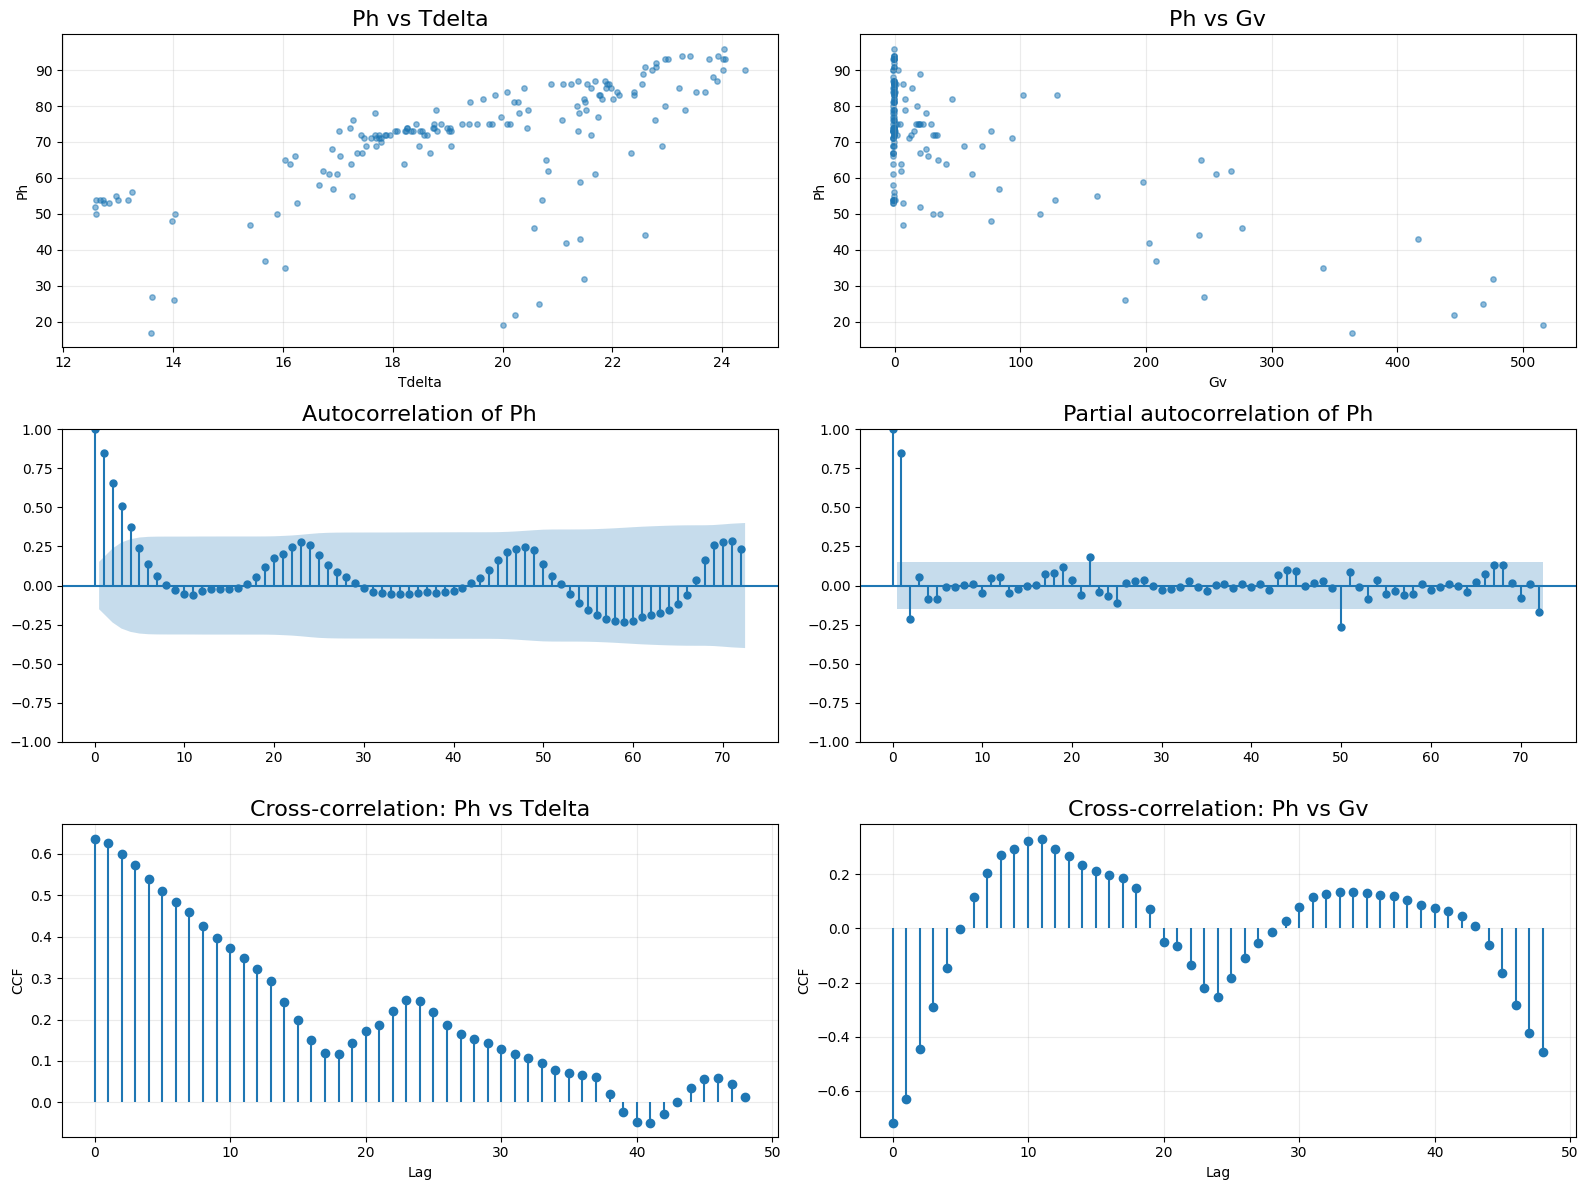

,Ph,Tdelta,Gv
Ph,1.000000,0.636687,-0.717565
Tdelta,0.636687,1.000000,-0.024887
Gv,-0.717565,-0.024887,1.000000


In [6]:
from statsmodels.tsa.stattools import ccf

train = Train.copy()
focus_columns = ["Ph", "Tdelta", "Gv"]
correlation_matrix = train[focus_columns].corr()

fig, axes = plt.subplots(3, 2, figsize=(16, 12))

scatter_pairs = [("Tdelta", "Ph"), ("Gv", "Ph")]
for ax, (x_col, y_col) in zip(axes[0, :], scatter_pairs):
    ax.scatter(train[x_col], train[y_col], s=15, alpha=0.5)
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(f"{y_col} vs {x_col}", fontsize=16)
    ax.grid(True, alpha=0.25)

sm.graphics.tsa.plot_acf(train["Ph"].dropna(), lags=72, ax=axes[1, 0])
axes[1, 0].set_title("Autocorrelation of Ph", fontsize=16)

sm.graphics.tsa.plot_pacf(train["Ph"].dropna(), lags=72, ax=axes[1, 1], method="ywm")
axes[1, 1].set_title("Partial autocorrelation of Ph", fontsize=16)

ph_tdelta = train[["Ph", "Tdelta"]].dropna()
ph_gv = train[["Ph", "Gv"]].dropna()

tdelta_ccf = ccf(ph_tdelta["Ph"], ph_tdelta["Tdelta"])
gv_ccf = ccf(ph_gv["Ph"], ph_gv["Gv"])

lag_limit = 48
lag_values = np.arange(0, lag_limit + 1)

axes[2, 0].stem(lag_values, tdelta_ccf[: lag_limit + 1], basefmt=" ")
axes[2, 0].set_title("Cross-correlation: Ph vs Tdelta", fontsize=16)
axes[2, 0].set_xlabel("Lag")
axes[2, 0].set_ylabel("CCF")
axes[2, 0].grid(True, alpha=0.25)

axes[2, 1].stem(lag_values, gv_ccf[: lag_limit + 1], basefmt=" ")
axes[2, 1].set_title("Cross-correlation: Ph vs Gv", fontsize=16)
axes[2, 1].set_xlabel("Lag")
axes[2, 1].set_ylabel("CCF")
axes[2, 1].grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

correlation_matrix.sort_values("Ph", ascending=False)

## Inpulse Response

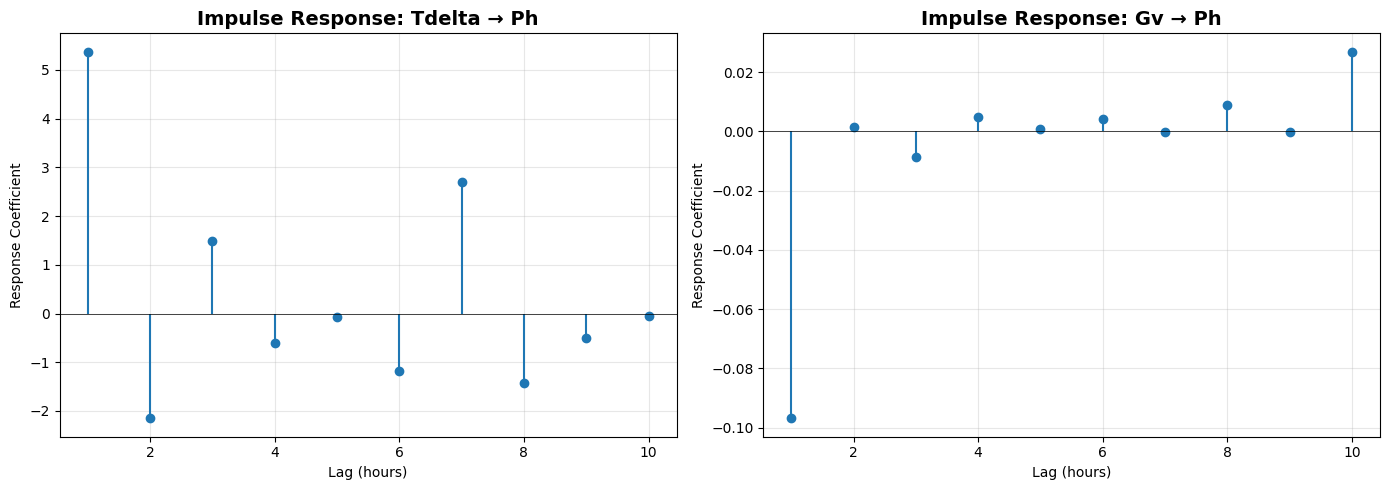

Impulse Response from Tdelta to Ph:
   Lag        IR
0    1  5.373823
1    2 -2.152076
2    3  1.492587
3    4 -0.611115
4    5 -0.074305
5    6 -1.176074
6    7  2.706299
7    8 -1.431220
8    9 -0.510640
9   10 -0.052223

Impulse Response from Gv to Ph:
   Lag        IR
0    1 -0.096900
1    2  0.001477
2    3 -0.008820
3    4  0.004979
4    5  0.000713
5    6  0.003990
6    7 -0.000279
7    8  0.008805
8    9 -0.000307
9   10  0.026878


In [7]:
train_data = Train.copy()

for lag in range(1, 11):
    train_data[f'Tdelta_lag{lag}'] = train_data['Tdelta'].shift(lag)

for lag in range(1, 11):
    train_data[f'Gv_lag{lag}'] = train_data['Gv'].shift(lag)

train_clean = train_data.dropna()

# Impulse response from Tdelta to Ph
tdelta_lags = [f'Tdelta_lag{lag}' for lag in range(1, 11)]
X_tdelta = sm.add_constant(train_clean[tdelta_lags])
model_tdelta = sm.OLS(train_clean['Ph'], X_tdelta).fit()
ir_tdelta = model_tdelta.params[1:].values  # Exclude constant

# Impulse response from Gv to Ph
gv_lags = [f'Gv_lag{lag}' for lag in range(1, 11)]
X_gv = sm.add_constant(train_clean[gv_lags])
model_gv = sm.OLS(train_clean['Ph'], X_gv).fit()
ir_gv = model_gv.params[1:].values  # Exclude constant

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

lags = np.arange(1, 11)

axes[0].stem(lags, ir_tdelta, basefmt=" ")
axes[0].axhline(y=0, color='k', linestyle='-', linewidth=0.5)
axes[0].set_title('Impulse Response: Tdelta → Ph', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Lag (hours)')
axes[0].set_ylabel('Response Coefficient')
axes[0].grid(True, alpha=0.3)

axes[1].stem(lags, ir_gv, basefmt=" ")
axes[1].axhline(y=0, color='k', linestyle='-', linewidth=0.5)
axes[1].set_title('Impulse Response: Gv → Ph', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Lag (hours)')
axes[1].set_ylabel('Response Coefficient')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Impulse Response from Tdelta to Ph:")
print(pd.DataFrame({'Lag': lags, 'IR': ir_tdelta}))
print("\nImpulse Response from Gv to Ph:")
print(pd.DataFrame({'Lag': lags, 'IR': ir_gv}))

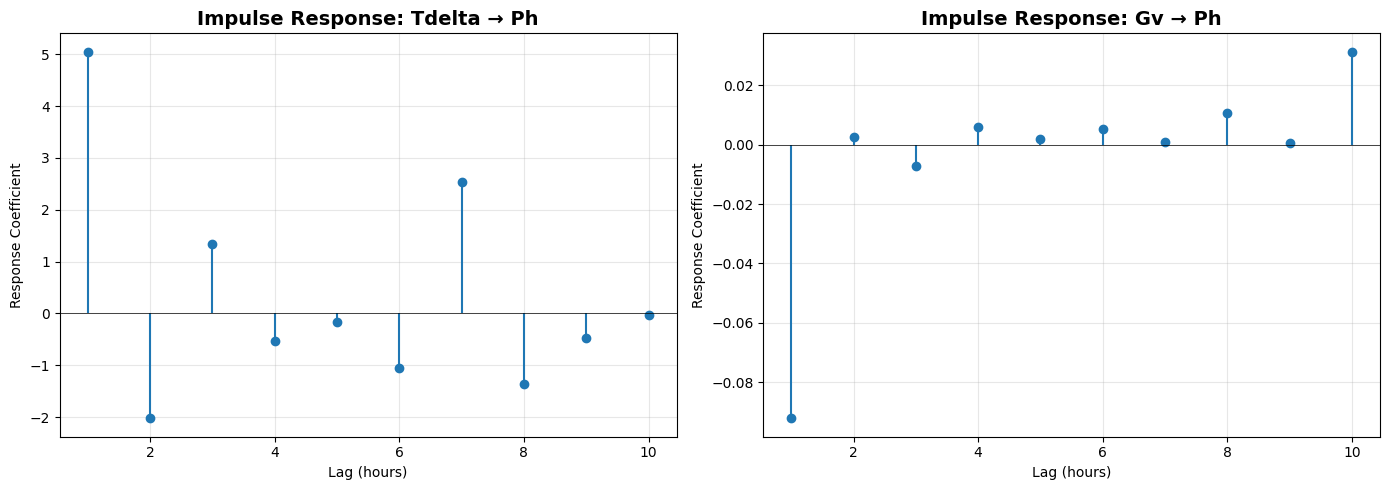

Impulse Response from Tdelta to Ph:
   Lag        IR
0    1  5.048218
1    2 -2.022576
2    3  1.348564
3    4 -0.539748
4    5 -0.165853
5    6 -1.052962
6    7  2.534330
7    8 -1.360696
8    9 -0.480041
9   10 -0.033249

Impulse Response from Gv to Ph:
   Lag        IR
0    1 -0.092155
1    2  0.002699
2    3 -0.007195
3    4  0.005982
4    5  0.002031
5    6  0.005376
6    7  0.000818
7    8  0.010769
8    9  0.000549
9   10  0.031275


In [14]:
# Impulse response using EXISTING lags from CSV (instead of manually creating them)

train_data = Train.copy()

# Impulse response from Tdelta to Ph - using existing lag columns
tdelta_lags = [f'Tdelta.l{lag}' for lag in range(1, 11)]
X_tdelta = sm.add_constant(train_data[tdelta_lags])
y_ph = train_data['Ph']
model_tdelta = sm.OLS(y_ph, X_tdelta).fit()
ir_tdelta = model_tdelta.params[1:].values  # Exclude constant

# Impulse response from Gv to Ph - using existing lag columns
gv_lags = [f'Gv.l{lag}' for lag in range(1, 11)]
X_gv = sm.add_constant(train_data[gv_lags])
model_gv = sm.OLS(y_ph, X_gv).fit()
ir_gv = model_gv.params[1:].values  # Exclude constant

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

lags = np.arange(1, 11)

axes[0].stem(lags, ir_tdelta, basefmt=" ")
axes[0].axhline(y=0, color='k', linestyle='-', linewidth=0.5)
axes[0].set_title('Impulse Response: Tdelta → Ph', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Lag (hours)')
axes[0].set_ylabel('Response Coefficient')
axes[0].grid(True, alpha=0.3)

axes[1].stem(lags, ir_gv, basefmt=" ")
axes[1].axhline(y=0, color='k', linestyle='-', linewidth=0.5)
axes[1].set_title('Impulse Response: Gv → Ph', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Lag (hours)')
axes[1].set_ylabel('Response Coefficient')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Impulse Response from Tdelta to Ph:")
print(pd.DataFrame({'Lag': lags, 'IR': ir_tdelta}))
print("\nImpulse Response from Gv to Ph:")
print(pd.DataFrame({'Lag': lags, 'IR': ir_gv}))

## 3.5. Fit the linear regression model

                            OLS Regression Results                            
Dep. Variable:                     Ph   R-squared:                       0.898
Model:                            OLS   Adj. R-squared:                  0.897
Method:                 Least Squares   F-statistic:                     722.6
Date:                Fri, 24 Apr 2026   Prob (F-statistic):           4.73e-82
Time:                        10:34:35   Log-Likelihood:                -510.21
No. Observations:                 167   AIC:                             1026.
Df Residuals:                     164   BIC:                             1036.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         11.1484      2.642      4.220      0.0

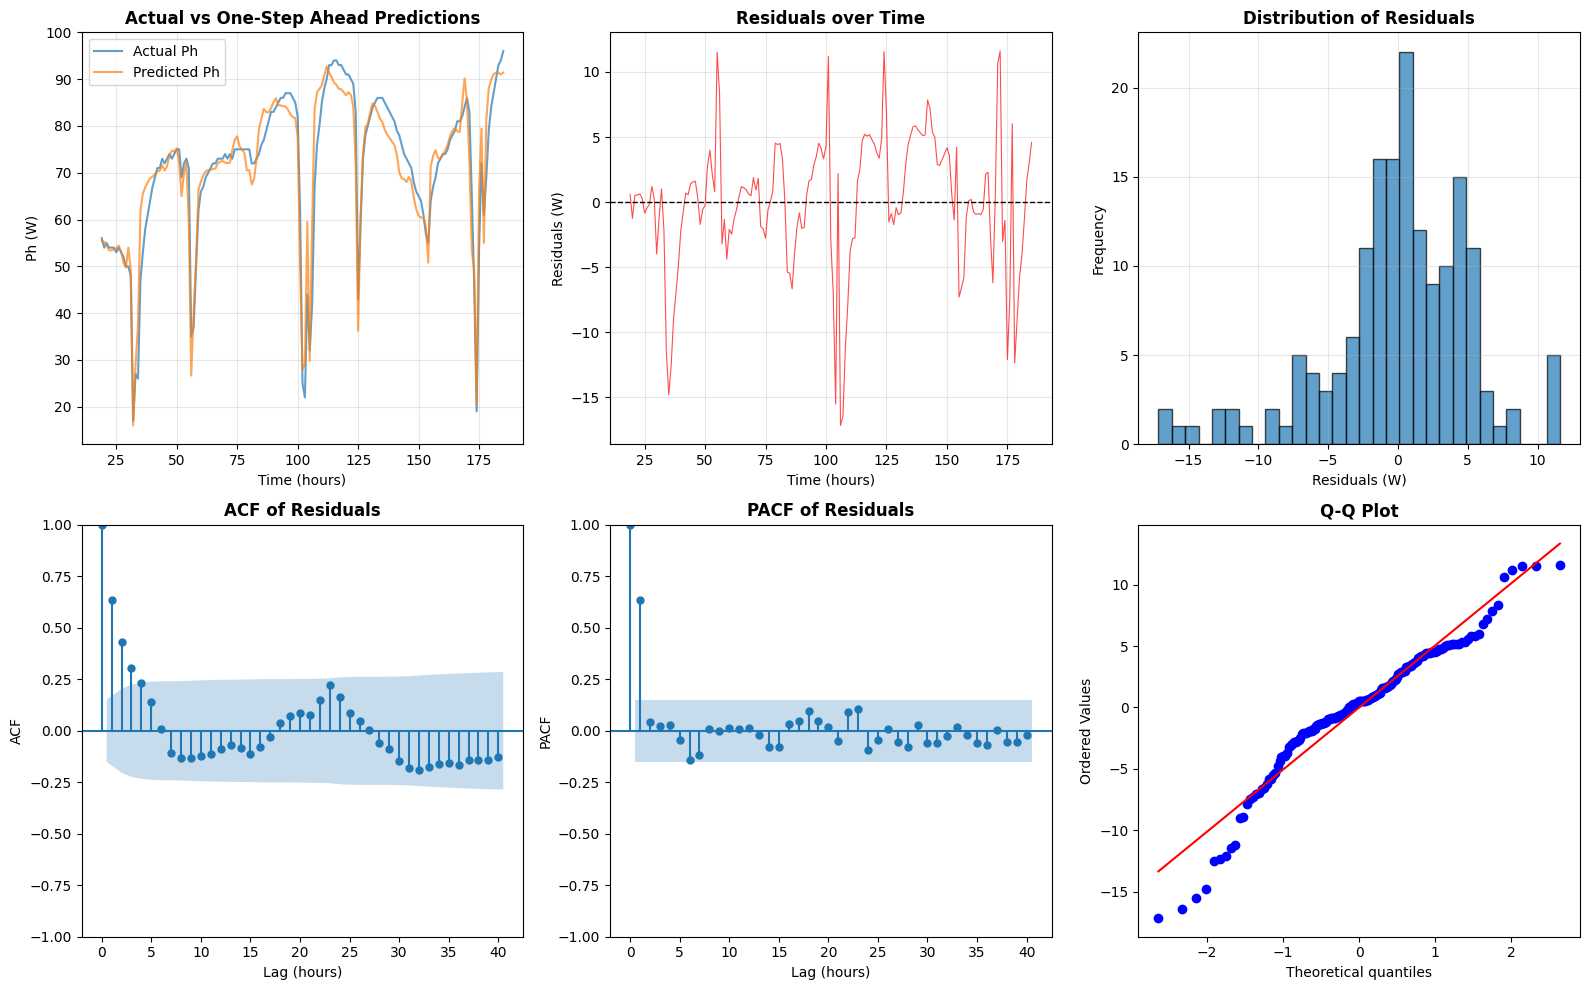

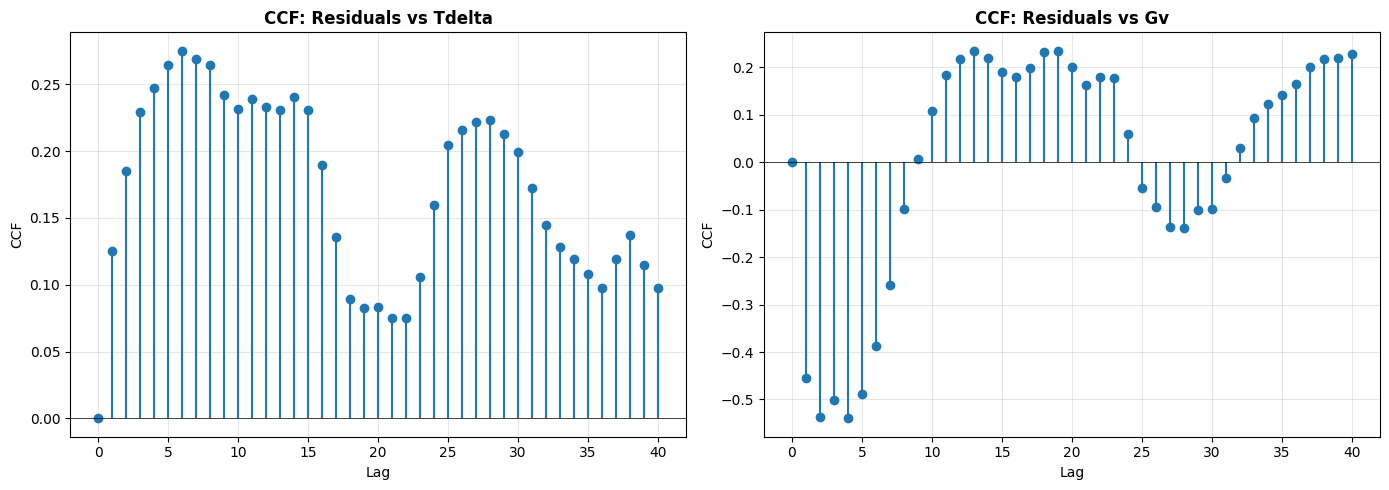


Model Diagnostics:
R-squared: 0.8981
Adjusted R-squared: 0.8968
Residual Std. Error: 5.1824
Mean of Residuals: -0.000000
Std. of Residuals: 5.1510
Durbin-Watson Statistic: 0.7235 (2.0 = no autocorrelation, <2 = positive autocorr.)


In [12]:
# Fit the linear regression model: Ph_t = ω1*Tdelta_t + ω2*Gv_t + ε_t

# Prepare data for regression (using training set)
train_model_data = Train.dropna()

# Define independent and dependent variables
X = sm.add_constant(train_model_data[['Tdelta', 'Gv']])
y = train_model_data['Ph']

# Fit OLS model
model = sm.OLS(y, X).fit()

# Print summary
print(model.summary())
print("\n" + "="*80 + "\n")

# Get one-step ahead predictions
predictions = model.fittedvalues
residuals = model.resid

# Verify and plot only training set
print(f"Training data range: thour {y.index.min()} to {y.index.max()}")
print(f"Number of training observations: {len(y)}")


# Create comprehensive diagnostic plots
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1. Actual vs Predicted
axes[0, 0].plot(y.index, y.values, label='Actual Ph', linewidth=1.5, alpha=0.7)
axes[0, 0].plot(predictions.index, predictions.values, label='Predicted Ph', linewidth=1.5, alpha=0.7)
axes[0, 0].set_title('Actual vs One-Step Ahead Predictions', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Time (hours)')
axes[0, 0].set_ylabel('Ph (W)')
#axes[0, 0].set_xlim(left=0, right=167)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Residuals over time
axes[0, 1].plot(residuals.index, residuals.values, linewidth=0.8, alpha=0.7, color='red')
axes[0, 1].axhline(y=0, color='k', linestyle='--', linewidth=1)
axes[0, 1].set_title('Residuals over Time', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Time (hours)')
axes[0, 1].set_ylabel('Residuals (W)')
axes[0, 1].grid(True, alpha=0.3)

# 3. Histogram of residuals
axes[0, 2].hist(residuals, bins=30, edgecolor='black', alpha=0.7)
axes[0, 2].set_title('Distribution of Residuals', fontsize=12, fontweight='bold')
axes[0, 2].set_xlabel('Residuals (W)')
axes[0, 2].set_ylabel('Frequency')
axes[0, 2].grid(True, alpha=0.3)

# 4. ACF of residuals
sm.graphics.tsa.plot_acf(residuals.dropna(), lags=40, ax=axes[1, 0])
axes[1, 0].set_title('ACF of Residuals', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Lag (hours)')
axes[1, 0].set_ylabel('ACF')

# 5. PACF of residuals
sm.graphics.tsa.plot_pacf(residuals.dropna(), lags=40, ax=axes[1, 1], method='ywm')
axes[1, 1].set_title('PACF of Residuals', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Lag (hours)')
axes[1, 1].set_ylabel('PACF')

# 6. Q-Q plot (normality check)
from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[1, 2])
axes[1, 2].set_title('Q-Q Plot', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Cross-correlation between residuals and inputs
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

tdelta_ccf = ccf(residuals, train_model_data['Tdelta'])
gv_ccf = ccf(residuals, train_model_data['Gv'])

lag_limit = 40
lag_values = np.arange(0, lag_limit + 1)

axes[0].stem(lag_values, tdelta_ccf[:lag_limit + 1], basefmt=" ")
axes[0].axhline(y=0, color='k', linestyle='-', linewidth=0.5)
axes[0].set_title('CCF: Residuals vs Tdelta', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Lag')
axes[0].set_ylabel('CCF')
axes[0].grid(True, alpha=0.3)

axes[1].stem(lag_values, gv_ccf[:lag_limit + 1], basefmt=" ")
axes[1].axhline(y=0, color='k', linestyle='-', linewidth=0.5)
axes[1].set_title('CCF: Residuals vs Gv', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Lag')
axes[1].set_ylabel('CCF')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Model diagnostics
print(f"\nModel Diagnostics:")
print(f"R-squared: {model.rsquared:.4f}")
print(f"Adjusted R-squared: {model.rsquared_adj:.4f}")
print(f"Residual Std. Error: {np.sqrt(model.mse_resid):.4f}")
print(f"Mean of Residuals: {residuals.mean():.6f}")
print(f"Std. of Residuals: {residuals.std():.4f}")

# Durbin-Watson statistic
from statsmodels.stats.stattools import durbin_watson
dw = durbin_watson(residuals)
print(f"Durbin-Watson Statistic: {dw:.4f} (2.0 = no autocorrelation, <2 = positive autocorr.)")

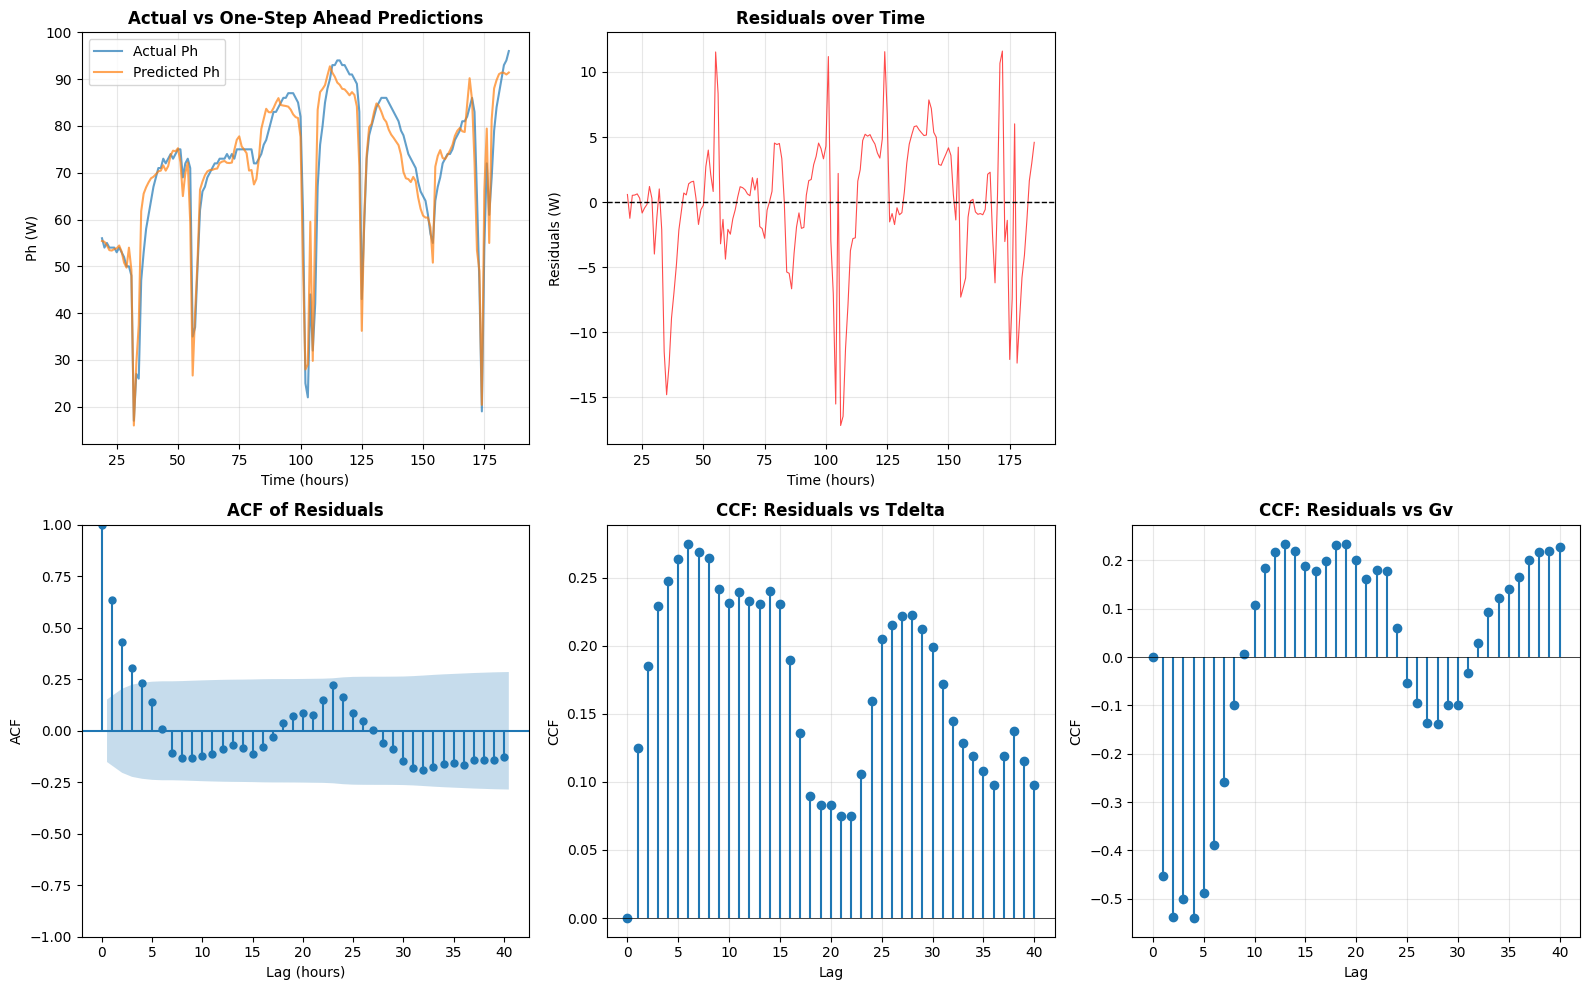

In [ ]:
# Create single comprehensive diagnostic figure
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1. Actual vs Predicted
axes[0, 0].plot(y.index, y.values, label='Actual Ph', linewidth=1.5, alpha=0.7)
axes[0, 0].plot(predictions.index, predictions.values, label='Predicted Ph', linewidth=1.5, alpha=0.7)
axes[0, 0].set_title('Actual vs One-Step Ahead Predictions', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Time (hours)')
axes[0, 0].set_ylabel('Ph (W)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Residuals over time
axes[0, 1].plot(residuals.index, residuals.values, linewidth=0.8, alpha=0.7, color='red')
axes[0, 1].axhline(y=0, color='k', linestyle='--', linewidth=1)
axes[0, 1].set_title('Residuals over Time', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Time (hours)')
axes[0, 1].set_ylabel('Residuals (W)')
axes[0, 1].grid(True, alpha=0.3)

# 3. PACF of residuals
sm.graphics.tsa.plot_pacf(residuals.dropna(), lags=40, ax=axes[0, 2], method='ywm')
axes[0, 2].set_title('PACF of Residuals', fontsize=12, fontweight='bold')
axes[0, 2].set_xlabel('Lag (hours)')
axes[0, 2].set_ylabel('PACF')

# 4. ACF of residuals
sm.graphics.tsa.plot_acf(residuals.dropna(), lags=40, ax=axes[1, 0])
axes[1, 0].set_title('ACF of Residuals', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Lag (hours)')
axes[1, 0].set_ylabel('ACF')

# 5. CCF: Residuals vs Tdelta
tdelta_ccf = ccf(residuals, train_model_data['Tdelta'])
lag_limit = 40
lag_values = np.arange(0, lag_limit + 1)
axes[1, 1].stem(lag_values, tdelta_ccf[:lag_limit + 1], basefmt=" ")
axes[1, 1].axhline(y=0, color='k', linestyle='-', linewidth=0.5)
axes[1, 1].set_title('CCF: Residuals vs Tdelta', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Lag')
axes[1, 1].set_ylabel('CCF')
axes[1, 1].grid(True, alpha=0.3)

# 6. CCF: Residuals vs Gv
gv_ccf = ccf(residuals, train_model_data['Gv'])
axes[1, 2].stem(lag_values, gv_ccf[:lag_limit + 1], basefmt=" ")
axes[1, 2].axhline(y=0, color='k', linestyle='-', linewidth=0.5)
axes[1, 2].set_title('CCF: Residuals vs Gv', fontsize=12, fontweight='bold')
axes[1, 2].set_xlabel('Lag')
axes[1, 2].set_ylabel('CCF')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()